# 03 — Funnel Analysis
Runs all funnel SQL queries and visualises drop-off, conversion by device, channel, and time.

**Prerequisite:** Run `01_data_generation.ipynb` first.

In [1]:
# Cell 1 — Imports & Connection
import sqlite3, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

BASE_DIR = Path('..').resolve()
DB_PATH  = BASE_DIR / 'data' / 'raw' / 'ecommerce.db'
assert DB_PATH.exists(), 'Run notebook 01 first'

conn = sqlite3.connect(DB_PATH)
print('Connected.')

Connected.


In [2]:
# Cell 2 — Overall Funnel: Unique Users per Stage
sql_overall = """
SELECT event_type,
       COUNT(DISTINCT user_id) AS unique_users
FROM   events
GROUP  BY event_type
"""
df_funnel = (
    pd.read_sql(sql_overall, conn)
    .set_index('event_type')
    .reindex(['page_view','product_view','add_to_cart','checkout_start','purchase'])
    .reset_index()
)
df_funnel.columns = ['stage','unique_users']

top = df_funnel['unique_users'].iloc[0]
df_funnel['conversion_from_top_pct'] = (df_funnel['unique_users'] / top * 100).round(2)
df_funnel['dropoff_from_prev_pct']   = 0.0
for i in range(1, len(df_funnel)):
    prev = df_funnel.loc[i-1, 'unique_users']
    curr = df_funnel.loc[i,   'unique_users']
    df_funnel.loc[i, 'dropoff_from_prev_pct'] = round((prev - curr) / prev * 100, 2)

print(df_funnel.to_string(index=False))

         stage  unique_users  conversion_from_top_pct  dropoff_from_prev_pct
     page_view          5000                   100.00                   0.00
  product_view          4829                    96.58                   3.42
   add_to_cart          3916                    78.32                  18.91
checkout_start          3012                    60.24                  23.08
      purchase          2381                    47.62                  20.95


In [3]:
# Cell 3 — Plotly Funnel Chart
stage_labels = ['Page View','Product View','Add to Cart','Checkout Start','Purchase']

fig = go.Figure(go.Funnel(
    y      = stage_labels,
    x      = df_funnel['unique_users'].tolist(),
    textinfo = 'value+percent initial',
    marker = dict(color=['#4C72B0','#55A868','#DD8452','#C44E52','#8172B2']),
    connector = dict(line=dict(color='royalblue', dash='dot', width=2))
))
fig.update_layout(
    title  = dict(text='E-Commerce Funnel — Unique Users', font=dict(size=18)),
    height = 480,
    margin = dict(l=20, r=20, t=60, b=20)
)
fig.show()

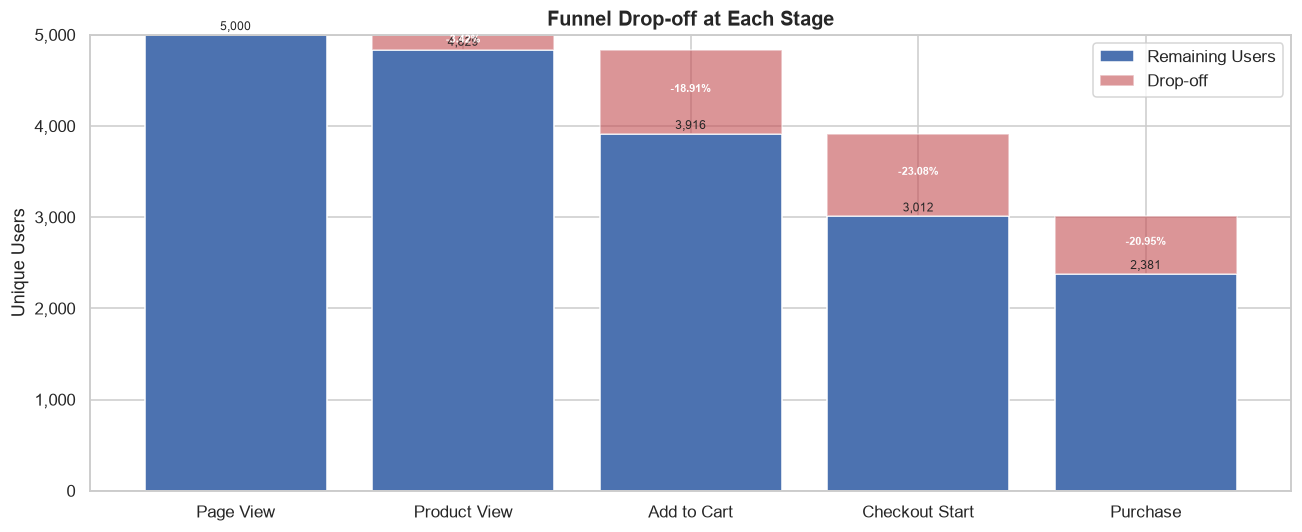

In [4]:
# Cell 4 — Drop-off Waterfall (Matplotlib)
labels  = stage_labels
users   = df_funnel['unique_users'].tolist()
drops   = [0] + [users[i-1] - users[i] for i in range(1, len(users))]

fig, ax = plt.subplots(figsize=(12, 5))
bars_stay = ax.bar(labels, users,   color='#4C72B0', label='Remaining Users')
bars_drop = ax.bar(labels, drops,   bottom=users, color='#C44E52', alpha=0.6, label='Drop-off')

for bar, u, d, pct in zip(bars_stay, users, drops,
                           df_funnel['dropoff_from_prev_pct'].tolist()):
    ax.text(bar.get_x() + bar.get_width()/2, u + 50, f'{u:,}', ha='center', fontsize=8)
    if d > 0:
        ax.text(bar.get_x() + bar.get_width()/2, u + d/2,
                f'-{pct}%', ha='center', color='white', fontsize=7, fontweight='bold')

ax.set_title('Funnel Drop-off at Each Stage', fontsize=13, fontweight='bold')
ax.set_ylabel('Unique Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'funnel_dropoff.png', bbox_inches='tight')
plt.show()

device_type  page_view  product_view  add_to_cart  checkout_start  purchase  overall_conv_pct
    desktop       4328          3947         2450            1605      1201             27.75
     mobile       4587          4256         2851            1913      1398             30.48
     tablet       2380          1865          851             513       366             15.38


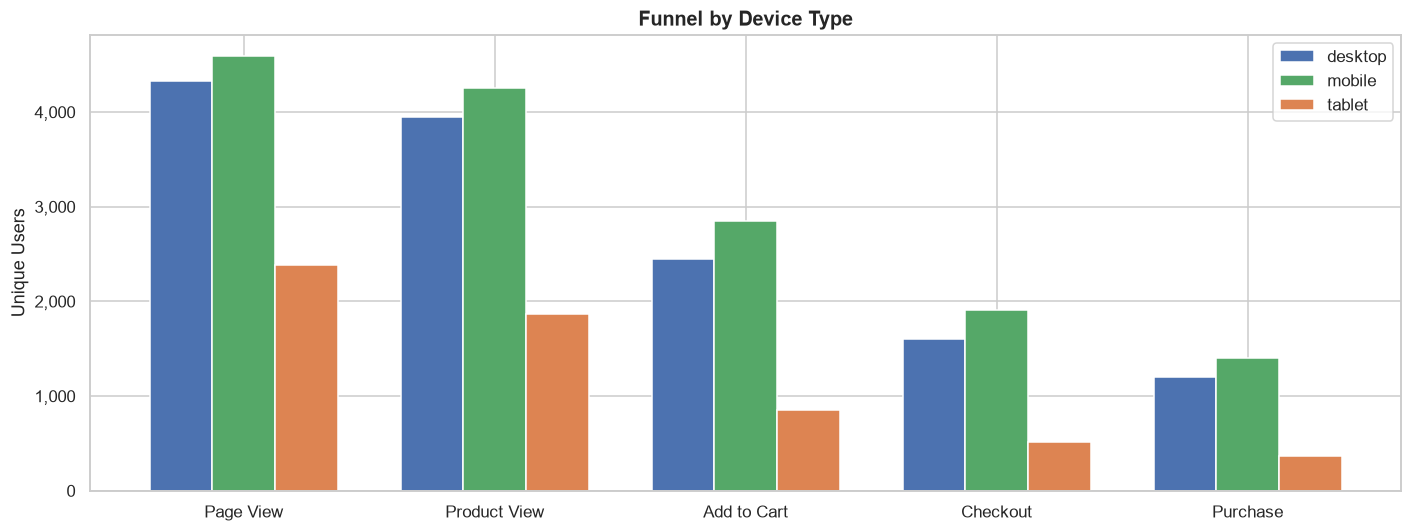

In [5]:
# Cell 5 — Funnel by Device Type
sql_device = """
SELECT s.device_type,
       COUNT(DISTINCT CASE WHEN e.event_type='page_view'      THEN e.user_id END) AS page_view,
       COUNT(DISTINCT CASE WHEN e.event_type='product_view'   THEN e.user_id END) AS product_view,
       COUNT(DISTINCT CASE WHEN e.event_type='add_to_cart'    THEN e.user_id END) AS add_to_cart,
       COUNT(DISTINCT CASE WHEN e.event_type='checkout_start' THEN e.user_id END) AS checkout_start,
       COUNT(DISTINCT CASE WHEN e.event_type='purchase'       THEN e.user_id END) AS purchase
FROM   events e
JOIN   sessions s ON e.session_id = s.session_id
GROUP  BY s.device_type
"""
df_device = pd.read_sql(sql_device, conn)
df_device['overall_conv_pct'] = (df_device['purchase'] / df_device['page_view'] * 100).round(2)
print(df_device.to_string(index=False))

# Grouped bar chart
stages = ['page_view','product_view','add_to_cart','checkout_start','purchase']
x = range(len(stages))
width = 0.25
colors_d = ['#4C72B0','#55A868','#DD8452']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (_, row) in enumerate(df_device.iterrows()):
    ax.bar([xi + i*width for xi in x], [row[s] for s in stages],
           width=width, label=row['device_type'], color=colors_d[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(['Page View','Product View','Add to Cart','Checkout','Purchase'])
ax.set_title('Funnel by Device Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Unique Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'funnel_by_device.png', bbox_inches='tight')
plt.show()

       channel  page_view  product_view  add_to_cart  checkout_start  purchase  conv_pct
organic_search       3920          3444         1897            1184       869     22.17
   paid_search       3613          3107         1670             991       720     19.93
  social_media       3222          2690         1336             791       559     17.35
         email       2654          2156          978             575       420     15.83
        direct       2662          2152         1023             609       414     15.55
      referral       1988          1558          711             405       282     14.19


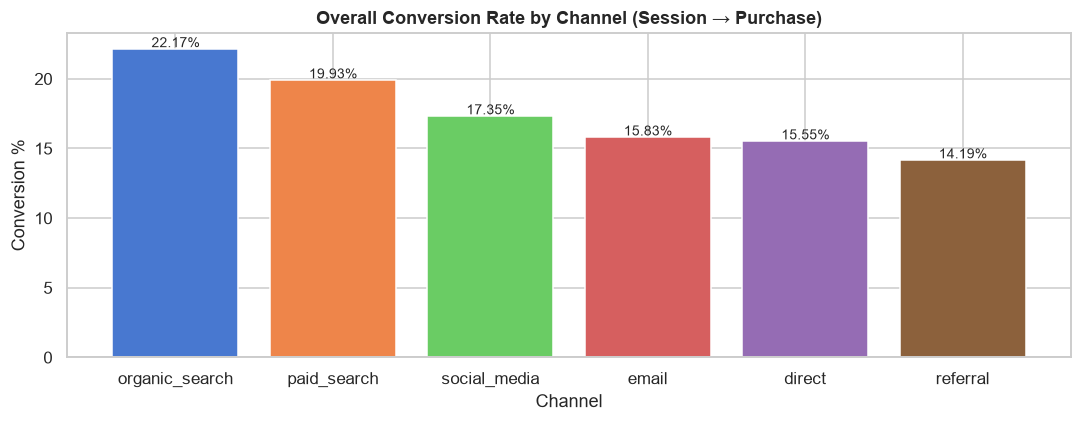

In [6]:
# Cell 6 — Funnel by Acquisition Channel
sql_channel = """
SELECT s.channel,
       COUNT(DISTINCT CASE WHEN e.event_type='page_view'      THEN e.user_id END) AS page_view,
       COUNT(DISTINCT CASE WHEN e.event_type='product_view'   THEN e.user_id END) AS product_view,
       COUNT(DISTINCT CASE WHEN e.event_type='add_to_cart'    THEN e.user_id END) AS add_to_cart,
       COUNT(DISTINCT CASE WHEN e.event_type='checkout_start' THEN e.user_id END) AS checkout_start,
       COUNT(DISTINCT CASE WHEN e.event_type='purchase'       THEN e.user_id END) AS purchase
FROM   events e
JOIN   sessions s ON e.session_id = s.session_id
GROUP  BY s.channel
ORDER  BY purchase DESC
"""
df_channel = pd.read_sql(sql_channel, conn)
df_channel['conv_pct'] = (df_channel['purchase'] / df_channel['page_view'] * 100).round(2)
print(df_channel.to_string(index=False))

# Conversion rate bar chart
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_channel['channel'], df_channel['conv_pct'],
              color=sns.color_palette('muted', len(df_channel)))
ax.set_title('Overall Conversion Rate by Channel (Session → Purchase)', fontsize=12, fontweight='bold')
ax.set_ylabel('Conversion %')
ax.set_xlabel('Channel')
for bar, val in zip(bars, df_channel['conv_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'funnel_by_channel.png', bbox_inches='tight')
plt.show()

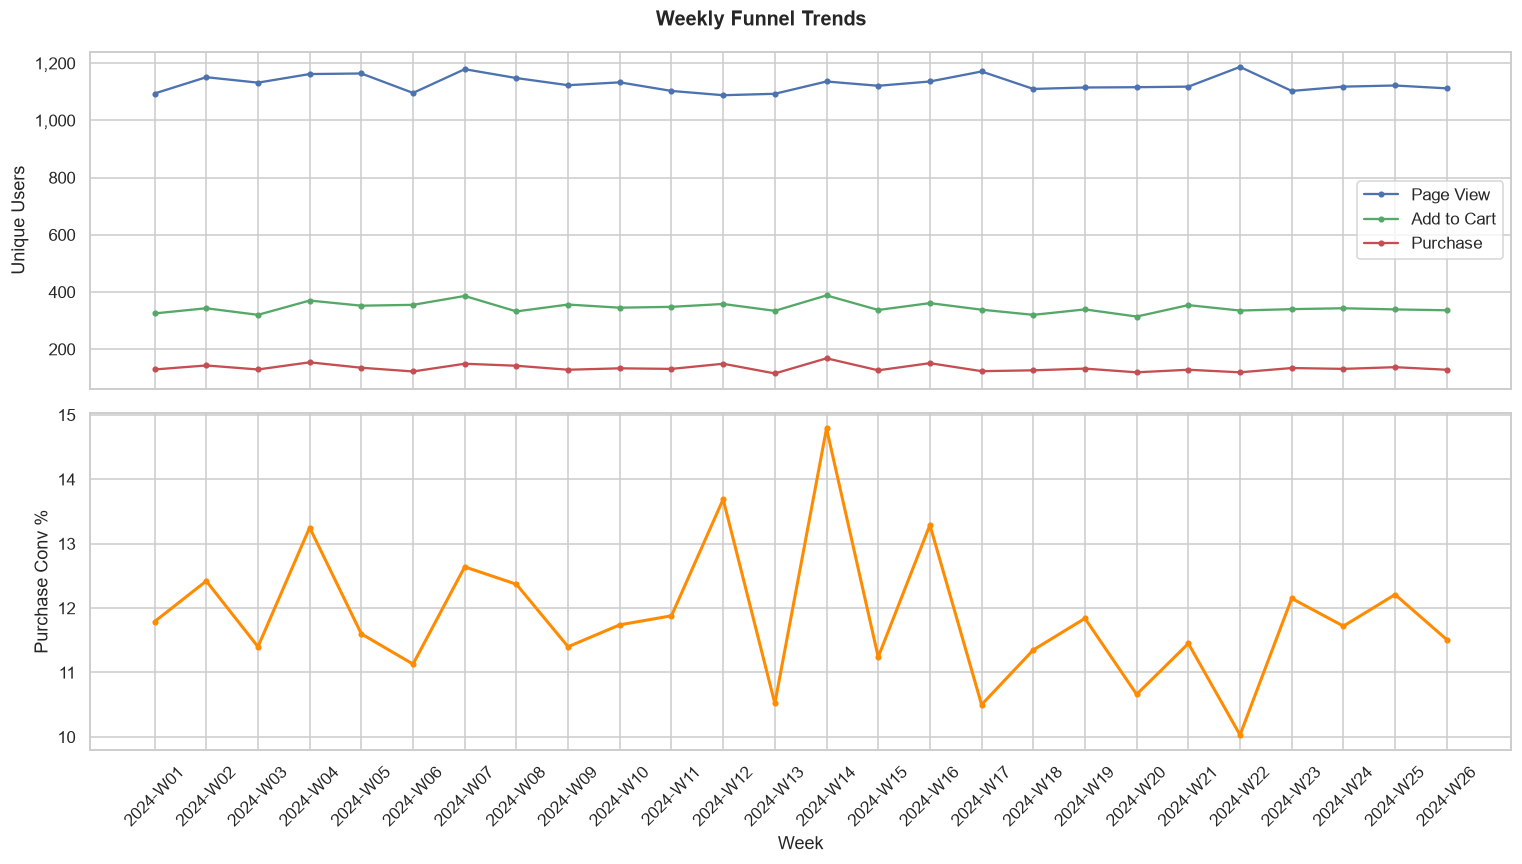

In [7]:
# Cell 7 — Weekly Funnel Trends
sql_weekly = """
SELECT strftime('%Y-W%W', e.timestamp) AS week,
       COUNT(DISTINCT CASE WHEN e.event_type='page_view'      THEN e.user_id END) AS page_view,
       COUNT(DISTINCT CASE WHEN e.event_type='product_view'   THEN e.user_id END) AS product_view,
       COUNT(DISTINCT CASE WHEN e.event_type='add_to_cart'    THEN e.user_id END) AS add_to_cart,
       COUNT(DISTINCT CASE WHEN e.event_type='checkout_start' THEN e.user_id END) AS checkout_start,
       COUNT(DISTINCT CASE WHEN e.event_type='purchase'       THEN e.user_id END) AS purchase
FROM   events e
GROUP  BY week
ORDER  BY week
"""
df_weekly = pd.read_sql(sql_weekly, conn)
df_weekly['purchase_conv_pct'] = (df_weekly['purchase'] / df_weekly['page_view'] * 100).round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Weekly Funnel Trends', fontsize=13, fontweight='bold')

for col, label, color in [
    ('page_view','Page View','#4C72B0'),
    ('add_to_cart','Add to Cart','#55A868'),
    ('purchase','Purchase','#C44E52')
]:
    axes[0].plot(df_weekly['week'], df_weekly[col], label=label, color=color, marker='o', markersize=3)

axes[0].set_ylabel('Unique Users')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].plot(df_weekly['week'], df_weekly['purchase_conv_pct'],
             color='darkorange', marker='o', markersize=3, linewidth=2)
axes[1].set_ylabel('Purchase Conv %')
axes[1].set_xlabel('Week')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'funnel_weekly_trends.png', bbox_inches='tight')
plt.show()

 product_id             product_name   subcategory   price  cart_adds  purchases  abandoned  abandonment_pct
         75          Alpha 7 IV (v2)       Cameras 2324.07        102         24         78             76.5
         21            AirPods Pro 2    Headphones  249.00         96         24         72             75.0
         80     QLED 65-inch 4K (v2)           TVs 1208.07        115         29         86             74.8
         46        65W USB-C Charger   Accessories   49.00        106         27         79             74.5
         24         Galaxy Buds2 Pro    Headphones  199.00        111         29         82             73.9
        120             Sense 2 (v3) Smart Watches  251.49         92         24         68             73.9
         84       PlayStation 5 (v2)        Gaming  503.99         84         22         62             73.8
         31                   Z6 III       Cameras 1999.00         91         24         67             73.6
         16        

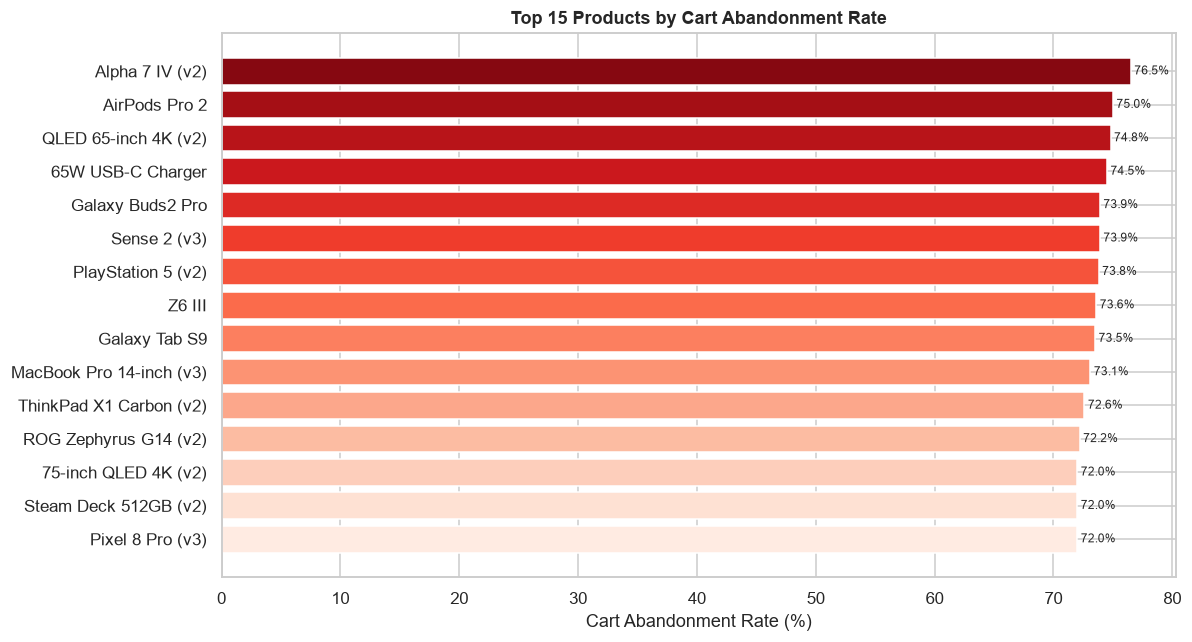

In [8]:
# Cell 8 — Top Abandoned Products (Cart but No Purchase)
sql_abandon = """
WITH cart AS (
    SELECT DISTINCT user_id, product_id FROM events WHERE event_type='add_to_cart' AND product_id IS NOT NULL
),
bought AS (
    SELECT DISTINCT oi.product_id, o.user_id
    FROM   order_items oi JOIN orders o ON oi.order_id=o.order_id WHERE o.status='completed'
),
aband AS (
    SELECT c.product_id,
           COUNT(*)            AS cart_adds,
           COUNT(b.user_id)    AS purchases,
           COUNT(*) - COUNT(b.user_id) AS abandoned
    FROM   cart c LEFT JOIN bought b ON c.product_id=b.product_id AND c.user_id=b.user_id
    GROUP  BY c.product_id
)
SELECT a.product_id, p.product_name, p.subcategory, p.price,
       a.cart_adds, a.purchases, a.abandoned,
       ROUND(100.0*a.abandoned/a.cart_adds,1) AS abandonment_pct
FROM   aband a JOIN products p ON a.product_id=p.product_id
ORDER  BY abandonment_pct DESC LIMIT 15
"""
df_abandon = pd.read_sql(sql_abandon, conn)
print(df_abandon.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
top15 = df_abandon.head(15)
ax.barh(top15['product_name'], top15['abandonment_pct'],
        color=sns.color_palette('Reds_r', len(top15)))
ax.set_xlabel('Cart Abandonment Rate (%)')
ax.set_title('Top 15 Products by Cart Abandonment Rate', fontsize=12, fontweight='bold')
for i, val in enumerate(top15['abandonment_pct']):
    ax.text(val + 0.3, i, f'{val}%', va='center', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'funnel_cart_abandonment.png', bbox_inches='tight')
plt.show()

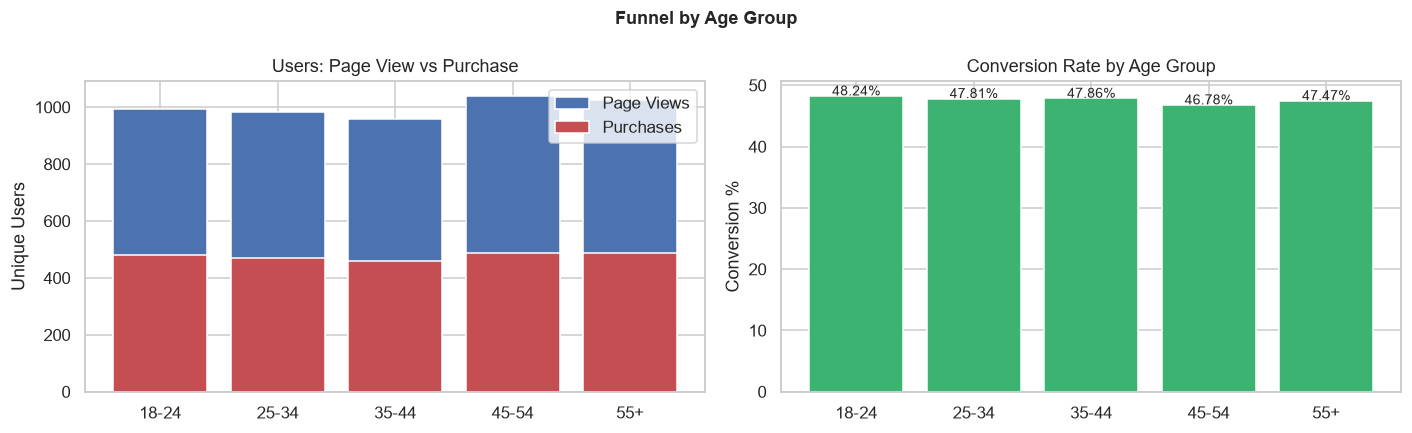

Done. All funnel charts saved.


In [9]:
# Cell 9 — Funnel by Age Group
sql_age = """
SELECT u.age_group,
       COUNT(DISTINCT CASE WHEN e.event_type='page_view'  THEN e.user_id END) AS page_view,
       COUNT(DISTINCT CASE WHEN e.event_type='purchase'   THEN e.user_id END) AS purchase
FROM   events e JOIN users u ON e.user_id=u.user_id
GROUP  BY u.age_group ORDER BY u.age_group
"""
df_age = pd.read_sql(sql_age, conn)
df_age['conv_pct'] = (df_age['purchase'] / df_age['page_view'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Funnel by Age Group', fontsize=12, fontweight='bold')

axes[0].bar(df_age['age_group'], df_age['page_view'], color='#4C72B0', label='Page Views')
axes[0].bar(df_age['age_group'], df_age['purchase'],  color='#C44E52', label='Purchases')
axes[0].set_title('Users: Page View vs Purchase')
axes[0].set_ylabel('Unique Users')
axes[0].legend()

axes[1].bar(df_age['age_group'], df_age['conv_pct'], color='mediumseagreen')
axes[1].set_title('Conversion Rate by Age Group')
axes[1].set_ylabel('Conversion %')
for i, v in enumerate(df_age['conv_pct']):
    axes[1].text(i, v + 0.1, f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'funnel_by_age.png', bbox_inches='tight')
plt.show()

conn.close()
print('Done. All funnel charts saved.')

---
**Next:** Open `04_revenue_analysis.ipynb`